In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np
import pandas as pd
from torch import nn
import timm
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap

In [2]:
class EmbNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model("tiny_vit_5m_224.dist_in22k_ft_in1k", pretrained=True, num_classes=0)

    def forward(self, image):
        x = self.model(image)
        return x

In [3]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('neoai-2025-cluster-pictures')

In [4]:
def generate_submit(pred_cluster):
    import hashlib
    sub = pd.DataFrame()
    sub['id'] = np.arange(len(pred_cluster))
    sub['target'] = pred_cluster
    hsh = hashlib.sha256(sub.to_csv(index=False).encode('utf-8')).hexdigest()[:8]
    submit_path = f"submit_{hsh}.csv"
    print(f"SUBMIT_NAME: {submit_path}")
    print(sub.head(10))
    sub.to_csv(submit_path, index = None)


X_1 = np.load(path + '/data_1.npz')
X_1 = X_1.f.arr_0
X_2 = np.load(path + '/data_2.npz')
X_2 = X_2.f.arr_0

km = KMeans(32)
X = np.concatenate((X_1.reshape((X_1.shape[0], X_1.shape[1] * X_1.shape[2])), X_2.reshape((X_2.shape[0], X_2.shape[1] * X_2.shape[2]))), 1)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

pred_cluster = km.fit_predict(x_scaled)

generate_submit(pred_cluster)

SUBMIT_NAME: submit_cf3df133.csv
   id  target
0   0       8
1   1      30
2   2      18
3   3       2
4   4       6
5   5      23
6   6      12
7   7      23
8   8      10
9   9       2


(array([660., 104.,  60.,  58.,  33.,  40.,  24.,  20.,  12.,  13.]),
 array([4.44252364e-05, 6.62934208e+00, 1.32586403e+01, 1.98879375e+01,
        2.65172348e+01, 3.31465340e+01, 3.97758331e+01, 4.64051285e+01,
        5.30344276e+01, 5.96637268e+01, 6.62930222e+01]),
 <BarContainer object of 10 artists>)

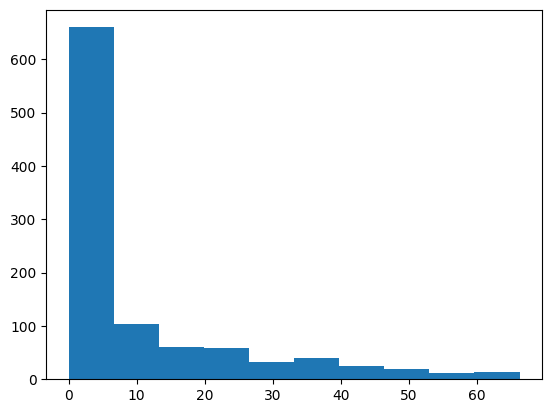

In [5]:
plt.hist(X[0])

(array([ 65., 333., 222., 140., 111.,  95.,  25.,  17.,  14.,   2.]),
 array([-2.02977467, -1.3961761 , -0.76257753, -0.12897897,  0.5046196 ,
         1.13821816,  1.77181673,  2.40541553,  3.03901386,  3.67261219,
         4.30621099]),
 <BarContainer object of 10 artists>)

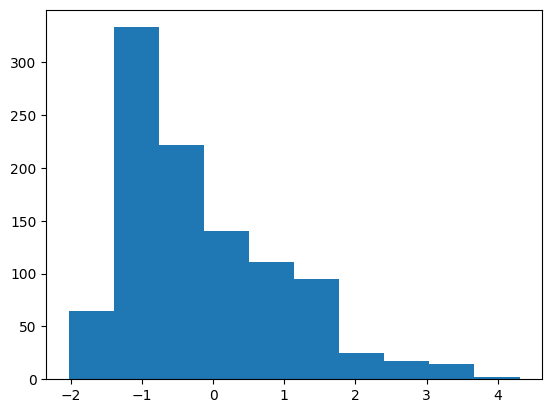

In [6]:
plt.hist(x_scaled[0])

In [7]:
pred_cluster

array([ 8, 30, 18, ..., 31, 26,  5], shape=(3840,), dtype=int32)

In [8]:
X.shape

(3840, 1024)

[0.1118155  0.06493912]


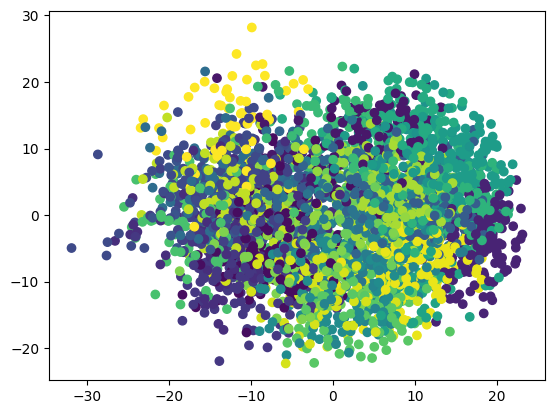

In [9]:
pca = PCA(n_components=2)
res = pca.fit_transform(x_scaled)
plt.scatter(res[:,0], res[:,1], c=pred_cluster, )
print(pca.explained_variance_ratio_)

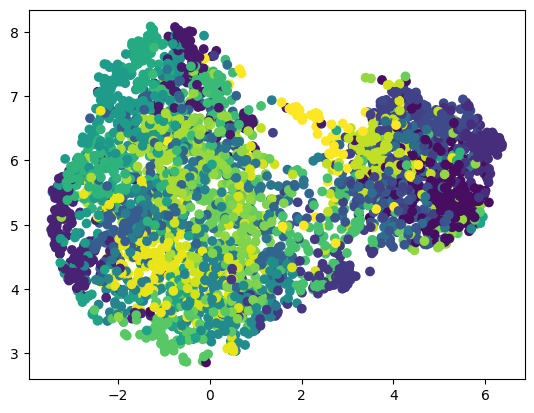

In [10]:
_umap = umap.UMAP(n_components=2)
res = _umap.fit_transform(x_scaled)
plt.scatter(res[:,0], res[:,1], c=pred_cluster, )

In [11]:
# from sklearn.cluster import SpectralClustering
# sc = SpectralClustering(32)
# pred_sc = sc.fit_predict(x_scaled)

In [ ]:
# plt.scatter(res[:,0], res[:,1], c=pred_sc)

NameError: name 'pred_sc' is not defined

In [13]:
X = X.reshape((-1, 1, 32, 32))
X_3channel = np.repeat(X, 3, axis=1)

In [14]:
import torch
from torch.utils.data import TensorDataset, DataLoader
tensor_imgs = torch.tensor(X_3channel, dtype=torch.float32)
dataset = TensorDataset(tensor_imgs)
loader = DataLoader(dataset, batch_size=32)

In [15]:
from tqdm import tqdm

model = EmbNet()
embeddings = []

for batch in tqdm(loader):
    embedding = model(batch[0])
    embeddings.append(embedding)

embeddings = torch.cat(embeddings)
embeddings.shape

 84%|████████▍ | 101/120 [00:48<00:09,  1.95it/s]

: 

In [ ]:
kmeans = KMeans(32)
embed_cluster = kmeans.fit_predict(embeddings)

In [ ]:
scaler = StandardScaler()
embed_scaled = scaler.fit_transform(embeddings)

pca = PCA(n_components=2)
res_pca = pca.fit_transform(embed_scaled)
plt.scatter(res[:,0], res[:,1], c=pred_cluster, )
print(pca.explained_variance_ratio_)